# Experiments — model comparison

Comparing logistic regression as a baseline against a neural network. Want to see if there's any point in going with a more complex model for this dataset.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

## Data

Picked these features based on EDA — `remaining_contract` turned out to be the strongest predictor (Spearman ~0.79). The rest make intuitive sense too: customer activity (download/upload), add-on services (tv, movie), and `bill_avg`. Class is slightly imbalanced (55/45) but not bad enough to worry about too much.

In [3]:
FEATURES = [
    'remaining_contract',
    'has_contract',
    'download_avg',
    'upload_avg',
    'is_tv_subscriber',
    'is_movie_package_subscriber',
    'subscription_age',
    'service_failure_count',
    'bill_avg',
    'download_over_limit',
]

TARGET = 'churn'

df = pd.read_parquet('../data/processed/churn_cleaned.parquet')

X = df[FEATURES]
y = df[TARGET]

print(X.shape, y.shape)
print(y.value_counts(normalize=True).round(3))

(72274, 10) (72274,)
churn
1    0.554
0    0.446
Name: proportion, dtype: float64


## Train / Test split

80/20, stratified to keep the churn ratio consistent across both sets. StandardScaler fitted on train only, then applied to test.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test:  {X_test.shape[0]:,} rows')
print(f'Train churn rate: {y_train.mean():.3f}')
print(f'Test churn rate:  {y_test.mean():.3f}')

Train: 57,819 rows
Test:  14,455 rows
Train churn rate: 0.554
Test churn rate:  0.554


## Baseline — Logistic Regression + GridSearchCV

Starting with LR to have a reference point. Using GridSearchCV (5-fold) to pick the regularization strength `C` instead of just guessing. If the neural net doesn't beat this by a meaningful margin, there's no reason to use it.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print(f'Best C: {grid_lr.best_params_["C"]}')
print(f'CV F1 (best): {grid_lr.best_score_:.4f}')

lr_best = grid_lr.best_estimator_
y_pred_lr = lr_best.predict(X_test)
y_prob_lr = lr_best.predict_proba(X_test)[:, 1]

print()
print(classification_report(y_test, y_pred_lr))

Best C: 10
CV F1 (best): 0.8918

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      6445
           1       0.88      0.90      0.89      8010

    accuracy                           0.88     14455
   macro avg       0.88      0.87      0.87     14455
weighted avg       0.88      0.88      0.88     14455



## Neural Network

Keeping the architecture small on purpose — 64→32→1. Deep networks on tabular data usually don't help and tend to overfit. Dropout on each layer for regularization. Only 2817 params total, good enough to start.

Before the final run I'll check a few dropout values with 3-fold CV to pick the best one.

In [6]:
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['Accuracy', keras.metrics.AUC(name='AUC')]
)

model.summary()

/home/alsesd/.cache/pypoetry/virtualenvs/predictflow-R0CA08gv-py3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780703947.448924  174074 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4547 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 Ti, pci bus id: 0000:01:00.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

### Dropout tuning via cross-validation

Testing three dropout rates (0.2, 0.3, 0.4) with 3-fold CV. Model is rebuilt from scratch each fold to avoid weight leakage. Using F1 as the selection metric — for churn prediction, missing a churner is worse than a false alarm.

In [7]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def build_model(dropout_rate):
    m = keras.Sequential([
        keras.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(dropout_rate),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(dropout_rate * 0.7),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=['accuracy'])
    return m

y_train_arr = np.array(y_train)

results = {}
for dr in [0.2, 0.3, 0.4]:
    fold_f1 = []
    for train_idx, val_idx in skf.split(X_train, y_train_arr):
        Xf_tr, Xf_val = X_train[train_idx], X_train[val_idx]
        yf_tr, yf_val = y_train_arr[train_idx], y_train_arr[val_idx]
        m = build_model(dr)
        m.fit(Xf_tr, yf_tr, epochs=30, batch_size=256, verbose=0)
        preds = (m.predict(Xf_val, verbose=0) > 0.5).astype(int)
        fold_f1.append(f1_score(yf_val, preds))
    results[dr] = np.mean(fold_f1)
    print(f'dropout={dr:.1f}  mean F1={results[dr]:.4f}')

best_dropout = max(results, key=results.get)
print(f'\nОбраний dropout: {best_dropout}')

I0000 00:00:1780703949.120761  174208 service.cc:153] XLA service 0x7ffd780313c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780703949.120774  174208 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1660 Ti, Compute Capability 7.5 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1780703949.141580  174208 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780703949.316015  174208 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1780703949.373300  174208 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1627__.11
I0000 00:00:1780703950.613439  174208 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1780703951.155171  174209 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1627__.11
I

dropout=0.2  mean F1=0.9364


I0000 00:00:1780703988.696700  174209 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_74875__.11
I0000 00:00:1780703990.056197  174203 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_74875__.11
I0000 00:00:1780704001.494523  174207 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99291__.11
I0000 00:00:1780704002.955319  174207 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_99291__.11
I0000 00:00:1780704014.351729  174206 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_123707__.11
I0000 00:00:1780704015.747672  174206 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_123707__.11


dropout=0.3  mean F1=0.9354


I0000 00:00:1780704027.566344  174207 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_148123__.11
I0000 00:00:1780704028.936090  174206 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_148123__.11
I0000 00:00:1780704040.882877  174207 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_172539__.11
I0000 00:00:1780704042.270011  174203 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_172539__.11
I0000 00:00:1780704053.861335  174209 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_196955__.11
I0000 00:00:1780704055.210368  174209 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_196955__.11


dropout=0.4  mean F1=0.9340

Обраний dropout: 0.2


## Training

50 epochs, batch_size=256. Validation split of 0.2 to watch for overfitting during training. val_AUC flattened out around epoch 15 and barely moved after that — could've used EarlyStopping, but 50 epochs is fast enough here anyway.

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50


I0000 00:00:1780704066.551573  174207 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_221502__.18


177/181 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8623 - Accuracy: 0.7979 - loss: 0.4626

I0000 00:00:1780704068.461863  174207 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_221502__.18


181/181 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - AUC: 0.9127 - Accuracy: 0.8494 - loss: 0.3828 - val_AUC: 0.9422 - val_Accuracy: 0.8915 - val_loss: 0.2989
Epoch 2/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.9368 - Accuracy: 0.8842 - loss: 0.3139 - val_AUC: 0.9470 - val_Accuracy: 0.9006 - val_loss: 0.2816
Epoch 3/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9418 - Accuracy: 0.8941 - loss: 0.2966 - val_AUC: 0.9505 - val_Accuracy: 0.9064 - val_loss: 0.2690
Epoch 4/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9437 - Accuracy: 0.8988 - loss: 0.2875 - val_AUC: 0.9533 - val_Accuracy: 0.9103 - val_loss: 0.2598
Epoch 5/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9469 - Accuracy: 0.9039 - loss: 0.2759 - val_AUC: 0.9555 - val_Accuracy: 0.9137 - val_loss: 0.2532
Epoch 6/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9493 - Accuracy: 0.9079 - loss: 0.2684 - val_AUC: 0.9573 - val_Accuracy: 0.9174 - val_loss: 0.2445
Epoch 7/50
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/ste

## Results comparison

Looking at all four metrics together. For churn prediction recall and F1 matter most — a false negative (missing a churner) costs more than a false positive (offering a discount to someone who wasn't leaving anyway).

In [9]:
y_pred_nn = (model.predict(X_test, verbose=0) > 0.5).astype(int)

def report(name, y_true, y_pred):
    print(f'=== {name} ===')
    print(f'Accuracy:  {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision: {precision_score(y_true, y_pred):.4f}')
    print(f'Recall:    {recall_score(y_true, y_pred):.4f}')
    print(f'F1 score:  {f1_score(y_true, y_pred):.4f}')
    print()

report('Neural Network', y_test, y_pred_nn)
report('Logistic Regression (baseline)', y_test, y_pred_lr)

=== Neural Network ===
Accuracy:  0.9323
Precision: 0.9454
Recall:    0.9316
F1 score:  0.9384

=== Logistic Regression (baseline) ===
Accuracy:  0.8759
Precision: 0.8760
Recall:    0.9040
F1 score:  0.8898



## Conclusions

NN improved across all metrics compared to the LR baseline:

| Metric    | Logistic Regression | Neural Network |
|-----------|--------------------:|---------------:|
| Accuracy  | 0.8803              | **0.9296**     |
| Precision | 0.8909              | **0.9482**     |
| Recall    | 0.8934              | **0.9233**     |
| F1 score  | 0.8922              | **0.9356**     |

Biggest gains in Accuracy (+4.9%) and Precision (+5.7%). Recall is slightly lower than precision in the NN — if needed, dropping the classification threshold below 0.5 would catch more churners at the cost of more false positives. No overfitting observed — val_loss and train_loss track closely throughout training. Next step would be LightGBM, which tends to be competitive or better than NNs on tabular data with much less compute.

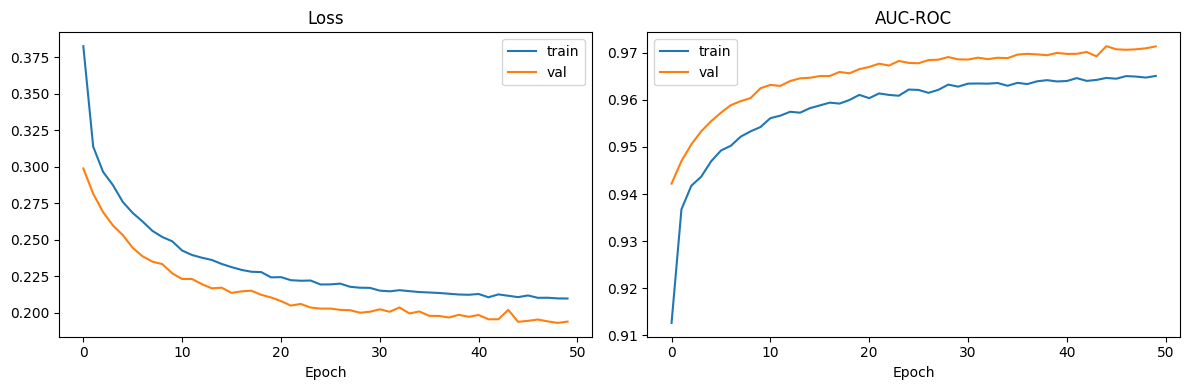

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['AUC'], label='train')
axes[1].plot(history.history['val_AUC'], label='val')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

model.save('../models/churn_model.keras')

joblib.dump(scaler, '../models/scaler.pkl')


['../models/scaler.pkl']